In [9]:
# ============================================================
# CELL 1 — MOUNT DRIVE + SET PATHS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, glob
from pathlib import Path

#  Change this if your file is in a different folder in Drive
DRIVE_ROOT = "/content/drive/MyDrive"

# Auto-find the dataset file (file OR folder with same name)
TARGET_NAME = "en.openfoodfacts.org.products.csv"

candidates = []
candidates += glob.glob(os.path.join(DRIVE_ROOT, "**", TARGET_NAME), recursive=True)

if len(candidates) == 0:
    raise FileNotFoundError(f"Could not find {TARGET_NAME} anywhere inside MyDrive. Please check the name.")

DATA_PATH = candidates[0]
print("Found path:", DATA_PATH)

# If it's a folder, find the CSV inside it
if os.path.isdir(DATA_PATH):
    inside = os.path.join(DATA_PATH, TARGET_NAME)
    if not os.path.exists(inside):
        raise FileNotFoundError(f"'{DATA_PATH}' is a folder but does not contain {TARGET_NAME}.")
    DATA_PATH = inside

print(" Using dataset file:", DATA_PATH)
print("File size (MB):", round(os.path.getsize(DATA_PATH)/1024/1024, 2))


Mounted at /content/drive
Found path: /content/drive/MyDrive/en.openfoodfacts.org.products.csv
 Using dataset file: /content/drive/MyDrive/en.openfoodfacts.org.products.csv/en.openfoodfacts.org.products.csv
File size (MB): 11661.82


In [10]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.stats import randint


In [11]:
# ============================================================
# CELL 3 — SAFE SEPARATOR DETECTION (NO DIRECTORY ERROR)
# ============================================================
def safe_openfoodfacts_path(path):
    # if user gave folder path, resolve to file inside
    if os.path.isdir(path):
        inner = os.path.join(path, os.path.basename(path))
        if os.path.exists(inner):
            return inner
        # try find any .csv inside
        csvs = glob.glob(os.path.join(path, "*.csv"))
        if csvs:
            return csvs[0]
        raise FileNotFoundError("Given path is a directory and no CSV found inside.")
    return path

DATA_PATH = safe_openfoodfacts_path(DATA_PATH)

def infer_sep(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        head = f.readline()
    # OpenFoodFacts exports are typically TAB-separated
    return "\t" if ("\t" in head and head.count("\t") > head.count(",")) else ","

sep = infer_sep(DATA_PATH)
print("Detected separator:", repr(sep))


Detected separator: '\t'


In [12]:
# ============================================================
# CELL 4 — SELECT COLUMNS + LOAD LIMITED ROWS (AVOID CRASH)
# ============================================================
USE_COLS = [
    "product_name",
    "code",
    "energy-kcal_100g",
    "fat_100g",
    "carbohydrates_100g",
    "proteins_100g",
    "sugars_100g",
    "fiber_100g",
    "salt_100g",
    "saturated-fat_100g",
    "sodium_100g"
]


NROWS = 200000

df = pd.read_csv(
    DATA_PATH,
    sep=sep,
    usecols=lambda c: c in USE_COLS,
    nrows=NROWS,
    low_memory=False,
    on_bad_lines="skip"
)

print("Loaded shape:", df.shape)
df.head()


Loaded shape: (200000, 11)


,code,product_name,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# ============================================================
# CELL 5 — QUICK DATA OVERVIEW
# ============================================================
print(df.info())
print("\nMissing %:")
print((df.isnull().mean()*100).sort_values(ascending=False).head(12))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                200000 non-null  int64  
 1   product_name        191579 non-null  object 
 2   energy-kcal_100g    165131 non-null  float64
 3   fat_100g            164238 non-null  float64
 4   saturated-fat_100g  149289 non-null  float64
 5   carbohydrates_100g  164716 non-null  float64
 6   sugars_100g         157094 non-null  float64
 7   fiber_100g          127440 non-null  float64
 8   proteins_100g       164414 non-null  float64
 9   salt_100g           150230 non-null  float64
 10  sodium_100g         150230 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 16.8+ MB
None

Missing %:
fiber_100g            36.2800
saturated-fat_100g    25.3555
salt_100g             24.8850
sodium_100g           24.8850
sugars_100g           21.4530
fat_100g 

In [14]:
# ============================================================
# CELL 6 — CLEAN DATA (REMOVE NaNs + NEGATIVE VALUES)
# ============================================================
numeric_cols = [c for c in USE_COLS if c not in ["product_name", "code"]]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

before = len(df)

# drop rows missing core nutrients + target
df = df.dropna(subset=["energy-kcal_100g", "fat_100g", "carbohydrates_100g", "proteins_100g"])
df = df.dropna()

# remove negative values
for c in numeric_cols:
    df = df[df[c] >= 0]

after = len(df)
print(f"Rows before: {before}, after: {after}, dropped: {before-after}")
df.head()


Rows before: 200000, after: 114007, dropped: 85993


,code,product_name,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
5,7,granola Bio le Chocolaté,1.0,1.00,1.000,1.0,1.00,1.00,1.00,1.0000,0.4000
8,9,xytitol pastilles,70.0,0.50,0.060,2.0,0.24,88.00,18.00,0.2750,0.1100
13,15,Madeleines ChocoLait,460.0,24.00,6.000,54.0,31.00,1.40,6.40,0.4800,0.1920
15,17,Collagen For Her,123.0,1.76,0.882,24.7,0.00,1.76,1.76,0.0882,0.0353
20,22,Farandole de madeleine,389.0,16.70,6.480,35.2,1.85,18.50,37.00,0.8800,0.3520


In [15]:
# ============================================================
# CELL 7 — OUTLIER REMOVAL (IQR CLIP)
# ============================================================
def iqr_filter(df_in, cols):
    df_out = df_in.copy()
    for c in cols:
        q1, q3 = df_out[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        df_out = df_out[(df_out[c] >= lo) & (df_out[c] <= hi)]
    return df_out

before2 = len(df)
df = iqr_filter(df, ["energy-kcal_100g","fat_100g","carbohydrates_100g","proteins_100g"])
after2 = len(df)
print(f"Rows before outlier filter: {before2}, after: {after2}")
df.head()


Rows before outlier filter: 114007, after: 97772


,code,product_name,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
5,7,granola Bio le Chocolaté,1.0,1.00,1.000,1.0,1.00,1.00,1.00,1.0000,0.4000
8,9,xytitol pastilles,70.0,0.50,0.060,2.0,0.24,88.00,18.00,0.2750,0.1100
13,15,Madeleines ChocoLait,460.0,24.00,6.000,54.0,31.00,1.40,6.40,0.4800,0.1920
15,17,Collagen For Her,123.0,1.76,0.882,24.7,0.00,1.76,1.76,0.0882,0.0353
28,31,Lindt Vollmilch Schokolade,6.0,0.30,0.200,0.5,0.20,0.10,0.30,0.8000,0.3200


In [16]:
# ============================================================
# CELL 8 — FEATURE ENGINEERING (CALCULATED KCAL)
# ============================================================
# Atwater factors: fat*9 + carbs*4 + protein*4
df["calc_kcal_100g"] = 9*df["fat_100g"] + 4*df["carbohydrates_100g"] + 4*df["proteins_100g"]

corr = df[["energy-kcal_100g","calc_kcal_100g"]].corr().iloc[0,1]
print("Corr(energy-kcal_100g vs calc_kcal_100g):", round(corr, 4))

df.head()


Corr(energy-kcal_100g vs calc_kcal_100g): 0.9792


,code,product_name,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,calc_kcal_100g
5,7,granola Bio le Chocolaté,1.0,1.00,1.000,1.0,1.00,1.00,1.00,1.0000,0.4000,17.00
8,9,xytitol pastilles,70.0,0.50,0.060,2.0,0.24,88.00,18.00,0.2750,0.1100,84.50
13,15,Madeleines ChocoLait,460.0,24.00,6.000,54.0,31.00,1.40,6.40,0.4800,0.1920,457.60
15,17,Collagen For Her,123.0,1.76,0.882,24.7,0.00,1.76,1.76,0.0882,0.0353,121.68
28,31,Lindt Vollmilch Schokolade,6.0,0.30,0.200,0.5,0.20,0.10,0.30,0.8000,0.3200,5.90


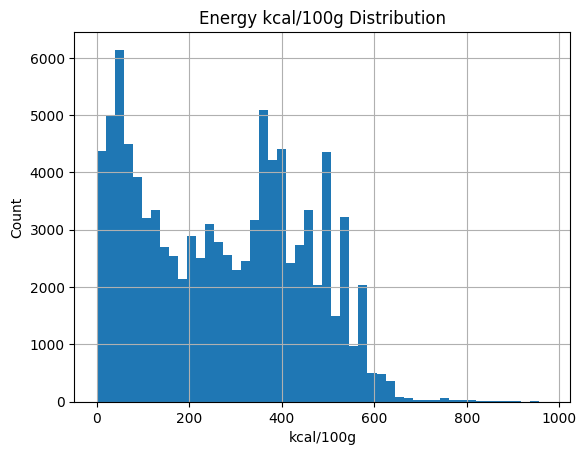

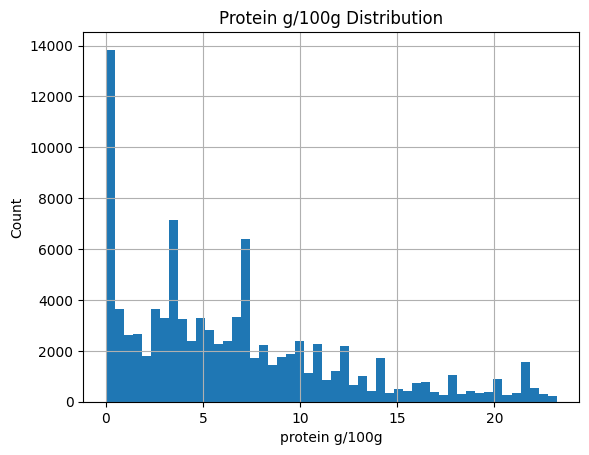

In [17]:
# ============================================================
# CELL 9 — EDA CHARTS (DISTRIBUTIONS)
# ============================================================
plt.figure()
df["energy-kcal_100g"].hist(bins=50)
plt.title("Energy kcal/100g Distribution")
plt.xlabel("kcal/100g")
plt.ylabel("Count")
plt.show()

plt.figure()
df["proteins_100g"].hist(bins=50)
plt.title("Protein g/100g Distribution")
plt.xlabel("protein g/100g")
plt.ylabel("Count")
plt.show()


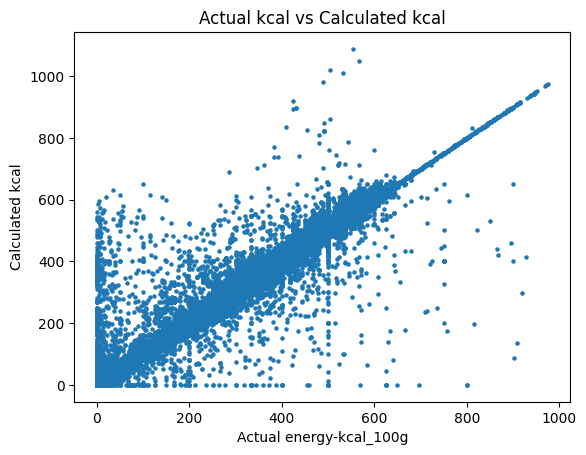

In [18]:
# ============================================================
# CELL 10 — EDA CHART (ACTUAL VS CALCULATED)
# ============================================================
plt.figure()
plt.scatter(df["energy-kcal_100g"], df["calc_kcal_100g"], s=5)
plt.title("Actual kcal vs Calculated kcal")
plt.xlabel("Actual energy-kcal_100g")
plt.ylabel("Calculated kcal")
plt.show()


In [19]:
# ============================================================
# CELL 11 — TRAIN/TEST SPLIT
# ============================================================
FEATURES = [
    "fat_100g",
    "carbohydrates_100g",
    "proteins_100g",
    "sugars_100g",
    "fiber_100g",
    "salt_100g",
    "sodium_100g",
    "saturated-fat_100g",
    "calc_kcal_100g"
]

X = df[FEATURES]
y = df["energy-kcal_100g"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (78217, 9) Test: (19555, 9)


In [20]:
# ============================================================
# CELL 12 — METRICS FUNCTION (RMSE FIXED FOR YOUR ERROR)
# ============================================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def regression_report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r = rmse(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {r:.4f}")
    print(f"R2  : {r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": r, "R2": r2}


Linear Regression
MAE : 13.4150
RMSE: 36.7641
R2  : 0.9571


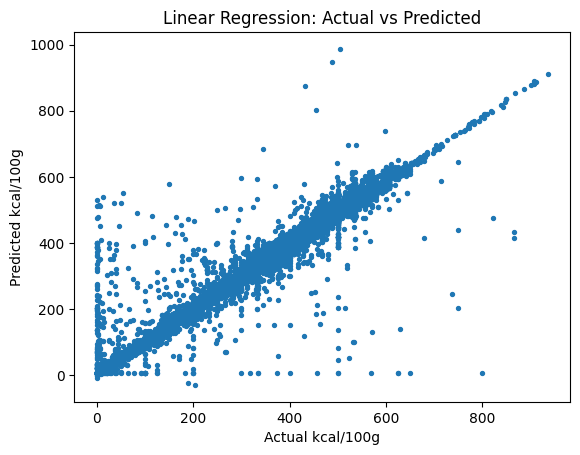

In [21]:
# ============================================================
# CELL 13 — MODEL 1: LINEAR REGRESSION (TRAIN + TEST)
# ============================================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_result = regression_report("Linear Regression", y_test, lr_preds)

plt.figure()
plt.scatter(y_test, lr_preds, s=8)
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual kcal/100g")
plt.ylabel("Predicted kcal/100g")
plt.show()


Decision Tree
MAE : 13.3641
RMSE: 36.6460
R2  : 0.9573


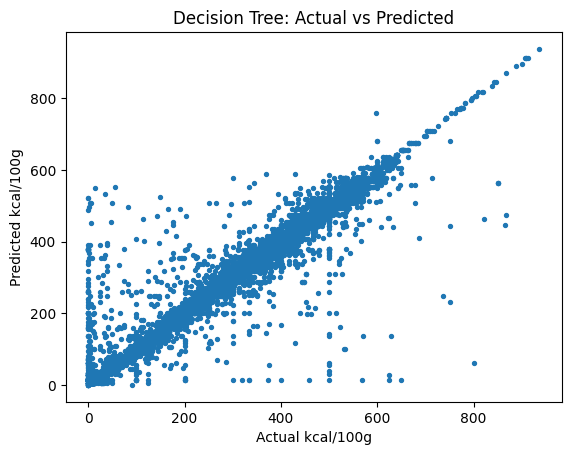

In [22]:
# ============================================================
# CELL 14 — MODEL 2: DECISION TREE (TRAIN + TEST)
# ============================================================
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=4
)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)
dt_result = regression_report("Decision Tree", y_test, dt_preds)

plt.figure()
plt.scatter(y_test, dt_preds, s=8)
plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual kcal/100g")
plt.ylabel("Predicted kcal/100g")
plt.show()


Random Forest
MAE : 11.2955
RMSE: 35.1633
R2  : 0.9607


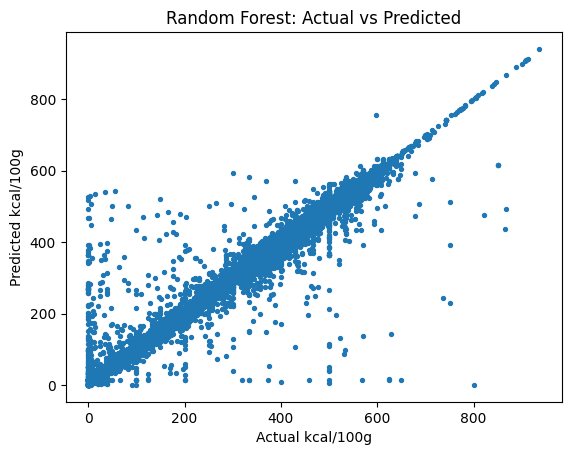

In [23]:
# ============================================================
# CELL 15 — MODEL 3: RANDOM FOREST (TRAIN + TEST)
# ============================================================
rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=250,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_result = regression_report("Random Forest", y_test, rf_preds)

plt.figure()
plt.scatter(y_test, rf_preds, s=8)
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual kcal/100g")
plt.ylabel("Predicted kcal/100g")
plt.show()


In [24]:
# ============================================================
# CELL 16 — COMPARE ALL 3 MODELS (TABLE)
# ============================================================
results_df = pd.DataFrame([lr_result, dt_result, rf_result]).sort_values("R2", ascending=False)
print(results_df.to_string(index=False))


            Model       MAE      RMSE       R2
    Random Forest 11.295512 35.163348 0.960729
    Decision Tree 13.364127 36.645995 0.957347
Linear Regression 13.414963 36.764138 0.957072


In [25]:
# ============================================================
# CELL 17 — OVERFITTING CHECK (TRAIN vs TEST R2)
# ============================================================
def train_test_r2(model, name):
    train_preds = model.predict(X_train)
    test_preds  = model.predict(X_test)
    train_r2 = r2_score(y_train, train_preds)
    test_r2  = r2_score(y_test, test_preds)
    print(f"{name} -> Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")

train_test_r2(lr_model, "Linear Regression")
train_test_r2(dt_model, "Decision Tree")
train_test_r2(rf_model, "Random Forest")


Linear Regression -> Train R2: 0.9599 | Test R2: 0.9571
Decision Tree -> Train R2: 0.9676 | Test R2: 0.9573
Random Forest -> Train R2: 0.9813 | Test R2: 0.9607


In [27]:
# ============================================================
# CELL 18 – RANDOM FOREST TUNING (FAST + STABLE)
# ============================================================

from scipy.stats import randint

rf_param_dist = {
    "n_estimators": randint(120, 220),
    "max_depth": randint(8, 18),
    "min_samples_split": randint(2, 6),
    "min_samples_leaf": randint(1, 4),
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_dist,
    n_iter=8,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=1
)

rf_search.fit(X_train, y_train)

print("Best CV R2:", rf_search.best_score_)
print("Best parameters:", rf_search.best_params_)


Best CV R2: 0.9644054157348151
Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 172}


Random Forest (Tuned)
MAE : 11.3810
RMSE: 34.3098
R2  : 0.9626


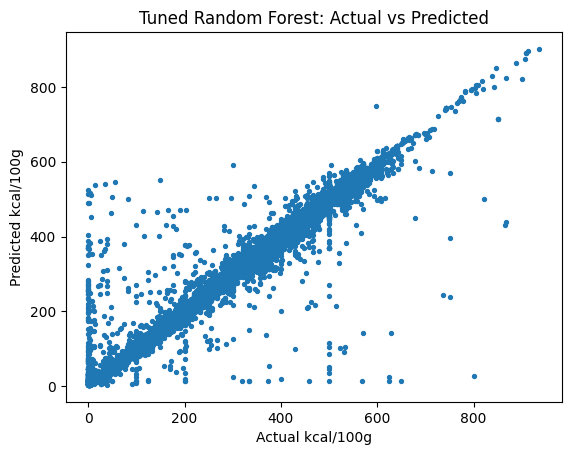

                Model       MAE      RMSE       R2
Random Forest (Tuned) 11.380980 34.309780 0.962612
        Random Forest 11.295512 35.163348 0.960729
        Decision Tree 13.364127 36.645995 0.957347
    Linear Regression 13.414963 36.764138 0.957072


In [28]:
# ============================================================
# CELL 19 — TEST TUNED RANDOM FOREST
# ============================================================
best_rf = rf_search.best_estimator_
best_rf.fit(X_train, y_train)

best_preds = best_rf.predict(X_test)
best_result = regression_report("Random Forest (Tuned)", y_test, best_preds)

plt.figure()
plt.scatter(y_test, best_preds, s=8)
plt.title("Tuned Random Forest: Actual vs Predicted")
plt.xlabel("Actual kcal/100g")
plt.ylabel("Predicted kcal/100g")
plt.show()

results_df2 = pd.DataFrame([lr_result, dt_result, rf_result, best_result]).sort_values("R2", ascending=False)
print(results_df2.to_string(index=False))


In [29]:
# ============================================================
# CELL 20 — USER INPUT SYSTEM (HEIGHT/WEIGHT/ACTIVITY)
# ============================================================
def get_user_profile():
    print("Enter user details:")
    age = float(input("Age: "))
    height_cm = float(input("Height (cm): "))
    weight_kg = float(input("Weight (kg): "))
    activity_minutes = float(input("Activity minutes per week: "))
    goal = input("Goal (lose/maintain/gain): ").strip().lower()
    return age, height_cm, weight_kg, activity_minutes, goal

# Uncomment to enable interactive input in Colab:
# age, height_cm, weight_kg, activity_minutes, goal = get_user_profile()

# Demo user (for automatic running)
age, height_cm, weight_kg, activity_minutes, goal = 20, 165, 60, 150, "maintain"
print("Demo user:", age, height_cm, weight_kg, activity_minutes, goal)


Demo user: 20 165 60 150 maintain


In [30]:
# ============================================================
# CELL 21 — CALORIE TARGET CALCULATION (SIMPLE)
# ============================================================
# Very simple calorie estimator for coursework demo
# (not medical-grade)

def calorie_target(height_cm, weight_kg, activity_minutes, goal):
    # base kcal estimate
    base = 22 * weight_kg

    # activity adjustment
    if activity_minutes < 60:
        base *= 1.1
    elif activity_minutes < 150:
        base *= 1.25
    else:
        base *= 1.4

    # goal adjustment
    if goal == "lose":
        base -= 300
    elif goal == "gain":
        base += 300

    return max(1200, base)

daily_kcal_target = calorie_target(height_cm, weight_kg, activity_minutes, goal)
meal_kcal_target = daily_kcal_target / 3
protein_target = weight_kg * 1.2  # grams/day

print("Daily kcal target:", round(daily_kcal_target, 2))
print("Meal kcal target:", round(meal_kcal_target, 2))
print("Daily protein target:", round(protein_target, 2))


Daily kcal target: 1848.0
Meal kcal target: 616.0
Daily protein target: 72.0


In [31]:
# ============================================================
# CELL 22 — FOOD RECOMMENDER (ENERGY + PROTEIN DISTANCE)
# ============================================================
def recommend_foods(df_in, target_kcal=250, target_protein=15, top_n=5):
    df_r = df_in.copy()

    # Ensure numeric
    df_r["energy-kcal_100g"] = pd.to_numeric(df_r["energy-kcal_100g"], errors="coerce")
    df_r["proteins_100g"] = pd.to_numeric(df_r["proteins_100g"], errors="coerce")
    df_r["carbohydrates_100g"] = pd.to_numeric(df_r["carbohydrates_100g"], errors="coerce")
    df_r["fat_100g"] = pd.to_numeric(df_r["fat_100g"], errors="coerce")

    df_r = df_r.dropna(subset=["energy-kcal_100g", "proteins_100g", "carbohydrates_100g", "fat_100g"])

    # Score: distance
    df_r["score"] = (
        abs(df_r["energy-kcal_100g"] - target_kcal) +
        5 * abs(df_r["proteins_100g"] - target_protein)
    )

    # name column
    if "product_name" in df_r.columns:
        df_r["name"] = df_r["product_name"].fillna(df_r["code"].astype(str))
    else:
        df_r["name"] = df_r["code"].astype(str)

    return df_r.sort_values("score").head(top_n)[
        ["name", "energy-kcal_100g", "proteins_100g", "carbohydrates_100g", "fat_100g", "score"]
    ]

print("Top recommendations:")
recs = recommend_foods(df, target_kcal=meal_kcal_target, target_protein=protein_target/3, top_n=5)
recs


Top recommendations:


,name,energy-kcal_100g,proteins_100g,carbohydrates_100g,fat_100g,score
181109,Natural Almond Flour PROMO,615.0,23.10,23.10,46.20,5.5
125482,Honey Roasted Whole Peanuts,617.0,23.10,23.10,48.80,5.5
186617,Fettuccini In A Creamy Bacon Flavored Parmesan...,613.0,23.00,121.00,4.31,8.0
42771,Rigatoni,615.0,22.30,124.00,3.20,9.5
68394,Dry honey roasted peanuts,613.0,22.58,29.03,45.16,10.1


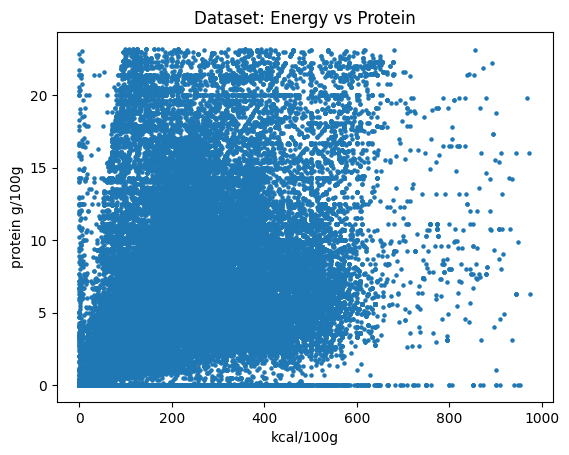

In [32]:
# ============================================================
# CELL 23 — RECOMMENDER CHART (ENERGY VS PROTEIN)
# ============================================================
plt.figure()
plt.scatter(df["energy-kcal_100g"], df["proteins_100g"], s=5)
plt.title("Dataset: Energy vs Protein")
plt.xlabel("kcal/100g")
plt.ylabel("protein g/100g")
plt.show()


In [33]:
# ============================================================
# CELL 24 — SAVE RESULTS TO CSV
# ============================================================
results_df2.to_csv("model_results.csv", index=False)
recs.to_csv("recommended_foods.csv", index=False)

print(" Saved: model_results.csv, recommended_foods.csv")


 Saved: model_results.csv, recommended_foods.csv


In [34]:
# ============================================================
# CELL 25 — FINAL SUMMARY
# ============================================================
best_model_name = results_df2.sort_values("R2", ascending=False).iloc[0]["Model"]
print("Best model:", best_model_name)
print("Done ")


Best model: Random Forest (Tuned)
Done 
